# PA1 — Segmentação de instâncias

Implementação gradual do trabalho de Aprendizado Profundo. Nesta primeira etapa, construiremos o teste unitário sintético exigido na Parte 0 do enunciado.

## Parte 0 — Dataset sintético

Cada imagem terá tamanho $128 \times 128$, entre 5 e 20 elipses, objetos frequentemente encostados e variações de ruído e contraste. O alvo é um mapa de instâncias: `0` representa o fundo e cada inteiro positivo identifica uma elipse diferente.

In [52]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
IMAGE_SIZE = 128
MIN_INSTANCES = 5
MAX_INSTANCES = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo selecionado: {device}")

if device.type == "cuda":
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name}")
    print(f"Memória total: {gpu.total_memory / 1024**3:.2f} GB")
    print(f"Compute capability: {gpu.major}.{gpu.minor}")

Dispositivo selecionado: cuda
GPU: Tesla T4
Memória total: 14.56 GB
Compute capability: 7.5


### Gerador de uma amostra

A função abaixo cria a imagem e seu mapa de instâncias simultaneamente. Parte das novas elipses é posicionada perto de uma elipse anterior para aumentar a frequência de objetos encostados. Uma posição só é aceita quando a elipse inteira cabe na imagem e não se sobrepõe a outra instância; portanto, cada forma permanece completa.

In [54]:
def ellipse_mask(height, width, center_y, center_x, radius_y, radius_x, angle):
    """Retorna uma máscara booleana para uma elipse rotacionada."""
    y, x = np.ogrid[:height, :width]
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    x_centered = x - center_x
    y_centered = y - center_y
    x_rot = x_centered * cos_a + y_centered * sin_a
    y_rot = -x_centered * sin_a + y_centered * cos_a
    return (x_rot / radius_x) ** 2 + (y_rot / radius_y) ** 2 <= 1


def dilate_one_pixel(mask):
    """Dilata uma máscara em um pixel usando vizinhança 8-conectada."""
    padded = np.pad(mask, 1, mode="constant")
    dilated = np.zeros_like(mask)
    for dy in range(3):
        for dx in range(3):
            dilated |= padded[dy : dy + mask.shape[0], dx : dx + mask.shape[1]]
    return dilated


def generate_synthetic_sample(rng, image_size=128, min_instances=5, max_instances=20):
    """Gera uma imagem em tons de cinza e um mapa de rótulos de instância."""
    height = width = image_size
    labels = np.zeros((height, width), dtype=np.int32)
    centers = []
    radii = []
    target_instances = int(rng.integers(min_instances, max_instances + 1))

    for instance_id in range(1, target_instances + 1):
        placed = False
        contact_requested = bool(centers and rng.random() < 0.70)

        for attempt in range(1_000):
            # Depois de 400 tentativas, usamos formas menores e priorizamos espaço livre.
            if attempt < 400:
                radius_y = int(rng.integers(5, 14))
                radius_x = int(rng.integers(5, 14))
            else:
                radius_y = int(rng.integers(4, 8))
                radius_x = int(rng.integers(4, 8))
            angle = float(rng.uniform(0, np.pi))
            try_contact = contact_requested and attempt < 400
            # Extensão do retângulo que contém a elipse após a rotação.
            extent_y = int(np.ceil(np.sqrt(
                (radius_x * np.sin(angle)) ** 2 + (radius_y * np.cos(angle)) ** 2
            )))
            extent_x = int(np.ceil(np.sqrt(
                (radius_x * np.cos(angle)) ** 2 + (radius_y * np.sin(angle)) ** 2
            )))

            if try_contact:
                neighbor_idx = int(rng.integers(len(centers)))
                neighbor_y, neighbor_x = centers[neighbor_idx]
                neighbor_ry, neighbor_rx = radii[neighbor_idx]
                direction = float(rng.uniform(0, 2 * np.pi))
                min_distance = min(neighbor_ry, neighbor_rx) + min(radius_y, radius_x)
                max_distance = max(neighbor_ry, neighbor_rx) + max(radius_y, radius_x) + 2
                distance = float(rng.uniform(min_distance, max_distance))
                center_y = int(round(neighbor_y + np.sin(direction) * distance))
                center_x = int(round(neighbor_x + np.cos(direction) * distance))
            else:
                center_y = int(rng.integers(extent_y, height - extent_y))
                center_x = int(rng.integers(extent_x, width - extent_x))

            if not (extent_y <= center_y < height - extent_y):
                continue
            if not (extent_x <= center_x < width - extent_x):
                continue

            candidate = ellipse_mask(
                height, width, center_y, center_x, radius_y, radius_x, angle
            )
            occupied = labels > 0
            overlaps = np.any(candidate & occupied)
            touches = not try_contact or np.any(dilate_one_pixel(candidate) & occupied)

            if overlaps or not touches:
                continue

            labels[candidate] = instance_id
            centers.append((center_y, center_x))
            radii.append((radius_y, radius_x))
            placed = True
            break

        if not placed:
            raise RuntimeError(
                f"Falha ao posicionar a instância {instance_id} de {target_instances}."
            )

    background = float(rng.uniform(0.05, 0.25))
    contrast = float(rng.uniform(0.45, 0.85))
    image = np.full((height, width), background, dtype=np.float32)
    for instance_id in np.unique(labels)[1:]:
        intensity = np.clip(background + contrast + rng.normal(0, 0.08), 0, 1)
        image[labels == instance_id] = intensity

    noise_std = float(rng.uniform(0.02, 0.12))
    image += rng.normal(0, noise_std, image.shape).astype(np.float32)
    image = np.clip(image, 0, 1)
    return image, labels

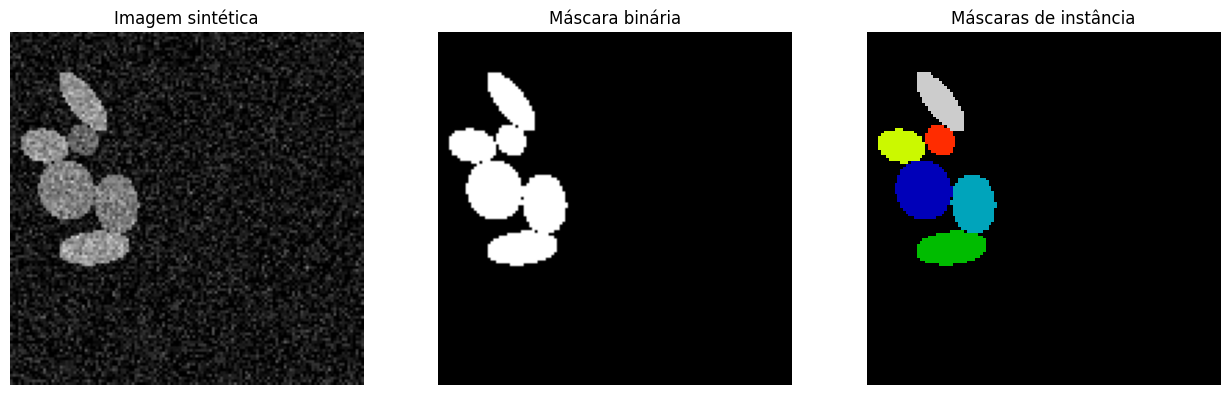

In [55]:
rng = np.random.default_rng(SEED)
sample_image, sample_labels = generate_synthetic_sample(rng, IMAGE_SIZE, MIN_INSTANCES, MAX_INSTANCES)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(sample_image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Imagem sintética")
axes[1].imshow(sample_labels > 0, cmap="gray")
axes[1].set_title("Máscara binária")
axes[2].imshow(sample_labels, cmap="nipy_spectral", interpolation="nearest")
axes[2].set_title("Máscaras de instância")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [56]:
instance_ids = np.unique(sample_labels)[1:]

assert sample_image.shape == (IMAGE_SIZE, IMAGE_SIZE)
assert sample_labels.shape == (IMAGE_SIZE, IMAGE_SIZE)
assert sample_image.dtype == np.float32
assert sample_labels.dtype == np.int32
assert np.isfinite(sample_image).all()
assert 0 <= sample_image.min() <= sample_image.max() <= 1
assert np.array_equal(instance_ids, np.arange(1, len(instance_ids) + 1))
assert MIN_INSTANCES <= len(instance_ids) <= MAX_INSTANCES

print(f"Instâncias geradas: {len(instance_ids)}")
print(f"Intervalo de intensidade: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
print("Validações básicas concluídas com sucesso.")

Instâncias geradas: 6
Intervalo de intensidade: [0.000, 0.909]
Validações básicas concluídas com sucesso.


### Dataset e DataLoaders

A classe abaixo adapta o gerador à interface do PyTorch. Cada índice usa uma seed própria, o que torna as amostras reproduzíveis. Ela devolve a imagem, a máscara binária usada no treinamento da baseline, a máscara de instâncias usada na avaliação e a quantidade de objetos.

In [57]:
from torch.utils.data import DataLoader, Dataset


class SyntheticEllipsesDataset(Dataset):
    def __init__(
        self,
        num_samples,
        base_seed,
        image_size=128,
        min_instances=5,
        max_instances=20,
    ):
        self.num_samples = num_samples
        self.base_seed = base_seed
        self.image_size = image_size
        self.min_instances = min_instances
        self.max_instances = max_instances
        self._cache = {}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        if index not in self._cache:
            rng = np.random.default_rng(self.base_seed + index)
            image, instance_mask = generate_synthetic_sample(
                rng=rng,
                image_size=self.image_size,
                min_instances=self.min_instances,
                max_instances=self.max_instances,
            )
            binary_mask = (instance_mask > 0).astype(np.float32)
            self._cache[index] = {
                "image": torch.from_numpy(image).unsqueeze(0),
                "binary_mask": torch.from_numpy(binary_mask).unsqueeze(0),
                "instance_mask": torch.from_numpy(instance_mask.astype(np.int64)),
                "num_instances": int(instance_mask.max()),
            }

        return self._cache[index]

In [58]:
TRAIN_SAMPLES = 800
VAL_SAMPLES = 160
TEST_SAMPLES = 160
BATCH_SIZE = 32

train_dataset = SyntheticEllipsesDataset(TRAIN_SAMPLES, base_seed=SEED)
val_dataset = SyntheticEllipsesDataset(VAL_SAMPLES, base_seed=SEED + 10_000)
test_dataset = SyntheticEllipsesDataset(TEST_SAMPLES, base_seed=SEED + 20_000)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda",
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Treino: {len(train_dataset)} imagens / {len(train_loader)} batches")
print(f"Validação: {len(val_dataset)} imagens / {len(val_loader)} batches")
print(f"Teste: {len(test_dataset)} imagens / {len(test_loader)} batches")

Treino: 800 imagens / 25 batches
Validação: 160 imagens / 5 batches
Teste: 160 imagens / 5 batches


In [59]:
first_batch = next(iter(train_loader))

assert first_batch["image"].shape == (BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["binary_mask"].shape == (BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["instance_mask"].shape == (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["image"].dtype == torch.float32
assert first_batch["binary_mask"].dtype == torch.float32
assert first_batch["instance_mask"].dtype == torch.int64
assert torch.equal(train_dataset[0]["image"], train_dataset[0]["image"])

print("Formato das imagens:       ", tuple(first_batch["image"].shape))
print("Formato das máscaras:      ", tuple(first_batch["binary_mask"].shape))
print("Formato das instâncias:    ", tuple(first_batch["instance_mask"].shape))
print("Objetos por imagem no lote:", first_batch["num_instances"].tolist())
print("Dataset e DataLoaders validados com sucesso.")

Formato das imagens:        (32, 1, 128, 128)
Formato das máscaras:       (32, 1, 128, 128)
Formato das instâncias:     (32, 128, 128)
Objetos por imagem no lote: [9, 7, 15, 5, 13, 18, 9, 20, 15, 18, 6, 18, 17, 10, 19, 20, 5, 6, 12, 5, 8, 10, 16, 6, 18, 10, 8, 19, 8, 13, 5, 7]
Dataset e DataLoaders validados com sucesso.


## U-Net pequena — baseline binária

A rede recebe uma imagem em tons de cinza e produz um logit por pixel. O encoder reduz a resolução para aprender contexto; o decoder recupera a resolução; e as *skip connections* concatenam detalhes do encoder ao decoder. A ativação sigmoide não faz parte do modelo: ela será aplicada apenas ao converter logits em probabilidades.

In [60]:
import torch.nn as nn


class DoubleConv(nn.Module):
    """Duas convoluções 3x3, cada uma seguida por BatchNorm e ReLU."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [61]:
class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c1, c2, c3, c4 = (
            base_channels,
            base_channels * 2,
            base_channels * 4,
            base_channels * 8,
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc1 = DoubleConv(in_channels, c1)
        self.enc2 = DoubleConv(c1, c2)
        self.enc3 = DoubleConv(c2, c3)
        self.bottleneck = DoubleConv(c3, c4)

        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c3 + c3, c3)
        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c2 + c2, c2)
        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c1 + c1, c1)
        self.head = nn.Conv2d(c1, out_channels, kernel_size=1)

    def forward(self, x):
        skip1 = self.enc1(x)
        skip2 = self.enc2(self.pool(skip1))
        skip3 = self.enc3(self.pool(skip2))
        x = self.bottleneck(self.pool(skip3))

        x = self.up3(x)
        x = self.dec3(torch.cat([x, skip3], dim=1))
        x = self.up2(x)
        x = self.dec2(torch.cat([x, skip2], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, skip1], dim=1))
        return self.head(x)

In [62]:
model = SmallUNet().to(device)
test_images = first_batch["image"][:2].to(device)

model.eval()
with torch.inference_mode():
    test_logits = model(test_images)

num_parameters = sum(parameter.numel() for parameter in model.parameters())
assert test_logits.shape == test_images.shape
assert test_logits.device == test_images.device
assert torch.isfinite(test_logits).all()

print(f"Entrada:    {tuple(test_images.shape)} em {test_images.device}")
print(f"Saída:      {tuple(test_logits.shape)} em {test_logits.device}")
print(f"Parâmetros: {num_parameters:,}")
print("Forward pass concluído com sucesso.")

Entrada:    (2, 1, 128, 128) em cuda:0
Saída:      (2, 1, 128, 128) em cuda:0
Parâmetros: 482,449
Forward pass concluído com sucesso.


### Perda e métricas semânticas

A baseline será otimizada com `BCEWithLogitsLoss`. Dice e IoU serão calculados após aplicar sigmoid e limiar de 0,5. Nesta etapa, essas métricas avaliam apenas foreground versus background; elas ainda não distinguem instâncias.

In [63]:
criterion = nn.BCEWithLogitsLoss()


def binary_segmentation_metrics(logits, targets, threshold=0.5, epsilon=1e-7):
    """Calcula Dice e IoU médios por imagem a partir dos logits."""
    probabilities = torch.sigmoid(logits)
    predictions = probabilities >= threshold
    targets = targets >= 0.5

    reduce_dims = tuple(range(1, predictions.ndim))
    intersection = (predictions & targets).sum(dim=reduce_dims).float()
    predicted_area = predictions.sum(dim=reduce_dims).float()
    target_area = targets.sum(dim=reduce_dims).float()
    union = predicted_area + target_area - intersection

    dice = (2 * intersection + epsilon) / (predicted_area + target_area + epsilon)
    iou = (intersection + epsilon) / (union + epsilon)
    return {"dice": dice.mean().item(), "iou": iou.mean().item()}

In [64]:
test_targets = first_batch["binary_mask"][:2].to(device)
test_loss = criterion(test_logits, test_targets)
untrained_metrics = binary_segmentation_metrics(test_logits, test_targets)

# Logits muito positivos no objeto e negativos no fundo simulam uma predição perfeita.
perfect_logits = torch.where(test_targets > 0.5, 20.0, -20.0)
perfect_metrics = binary_segmentation_metrics(perfect_logits, test_targets)

assert torch.isfinite(test_loss)
assert 0 <= untrained_metrics["dice"] <= 1
assert 0 <= untrained_metrics["iou"] <= 1
assert abs(perfect_metrics["dice"] - 1.0) < 1e-6
assert abs(perfect_metrics["iou"] - 1.0) < 1e-6

print(f"Loss antes do treino: {test_loss.item():.4f}")
print(
    f"Modelo não treinado — Dice: {untrained_metrics['dice']:.4f} | "
    f"IoU: {untrained_metrics['iou']:.4f}"
)
print(
    f"Teste perfeito       — Dice: {perfect_metrics['dice']:.4f} | "
    f"IoU: {perfect_metrics['iou']:.4f}"
)
print("Perda e métricas validadas com sucesso.")

Loss antes do treino: 0.6340
Modelo não treinado — Dice: 0.0000 | IoU: 0.0000
Teste perfeito       — Dice: 1.0000 | IoU: 1.0000
Perda e métricas validadas com sucesso.


### Pré-validação dos splits sintéticos

Antes do treinamento, percorremos uma vez todas as seeds de treino, validação e teste. Isso confirma que o gerador consegue construir cada amostra e que todas contêm entre 5 e 20 instâncias. Como a geração é determinística por índice, as mesmas seeds serão usadas durante o treinamento.

In [65]:
for split_name, dataset in (
    ("treino", train_dataset),
    ("validação", val_dataset),
    ("teste", test_dataset),
):
    counts = [dataset[index]["num_instances"] for index in range(len(dataset))]
    assert min(counts) >= MIN_INSTANCES
    assert max(counts) <= MAX_INSTANCES
    print(
        f"{split_name.capitalize():10s}: {len(counts):4d} imagens | "
        f"instâncias entre {min(counts)} e {max(counts)}"
    )

print("Todos os splits sintéticos foram validados com sucesso.")

Treino    :  800 imagens | instâncias entre 5 e 20
Validação :  160 imagens | instâncias entre 5 e 20
Teste     :  160 imagens | instâncias entre 5 e 20
Todos os splits sintéticos foram validados com sucesso.


### Treinamento da baseline sintética

Treinaremos por 10 épocas com Adam. A cada época, a rede é avaliada sem gradientes no conjunto de validação. Guardamos em memória os pesos da época com menor loss de validação e medimos o tempo total para verificar o requisito de menos de cinco minutos.

In [66]:
import copy
import time


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["binary_mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


@torch.inference_mode()
def evaluate_semantic(model, loader, criterion, device):
    model.eval()
    totals = {"loss": 0.0, "dice": 0.0, "iou": 0.0}
    total_samples = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["binary_mask"].to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, targets)
        metrics = binary_segmentation_metrics(logits, targets)

        batch_size = images.shape[0]
        totals["loss"] += loss.item() * batch_size
        totals["dice"] += metrics["dice"] * batch_size
        totals["iou"] += metrics["iou"] * batch_size
        total_samples += batch_size

    return {name: value / total_samples for name, value in totals.items()}

In [67]:
EPOCHS = 10
LEARNING_RATE = 1e-3

# Reinicialização explícita para o experimento ser reproduzível.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = SmallUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_val_loss = float("inf")
best_state = None
best_epoch = 0

start_time = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate_semantic(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Época {epoch:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_metrics['loss']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f}"
    )

elapsed_seconds = time.perf_counter() - start_time
model.load_state_dict(best_state)

print(f"\nMelhor época: {best_epoch} (val loss = {best_val_loss:.4f})")
print(f"Tempo total: {elapsed_seconds:.1f} s ({elapsed_seconds / 60:.2f} min)")
if elapsed_seconds <= 300:
    print("Requisito de treinamento em menos de 5 minutos atendido.")
else:
    print("Atenção: o treinamento ultrapassou 5 minutos.")

Época 01/10 | train loss: 0.4350 | val loss: 0.4124 | Dice: 0.9222 | IoU: 0.8561
Época 02/10 | train loss: 0.3402 | val loss: 0.3214 | Dice: 0.9859 | IoU: 0.9723
Época 03/10 | train loss: 0.2855 | val loss: 0.2629 | Dice: 0.9962 | IoU: 0.9924
Época 04/10 | train loss: 0.2401 | val loss: 0.2190 | Dice: 0.9973 | IoU: 0.9947
Época 05/10 | train loss: 0.2018 | val loss: 0.1851 | Dice: 0.9987 | IoU: 0.9975
Época 06/10 | train loss: 0.1694 | val loss: 0.1575 | Dice: 0.9988 | IoU: 0.9977
Época 07/10 | train loss: 0.1425 | val loss: 0.1303 | Dice: 0.9991 | IoU: 0.9983
Época 08/10 | train loss: 0.1204 | val loss: 0.1090 | Dice: 0.9994 | IoU: 0.9988
Época 09/10 | train loss: 0.1022 | val loss: 0.0948 | Dice: 0.9995 | IoU: 0.9990
Época 10/10 | train loss: 0.0868 | val loss: 0.0806 | Dice: 0.9996 | IoU: 0.9993

Melhor época: 10 (val loss = 0.0806)
Tempo total: 19.4 s (0.32 min)
Requisito de treinamento em menos de 5 minutos atendido.


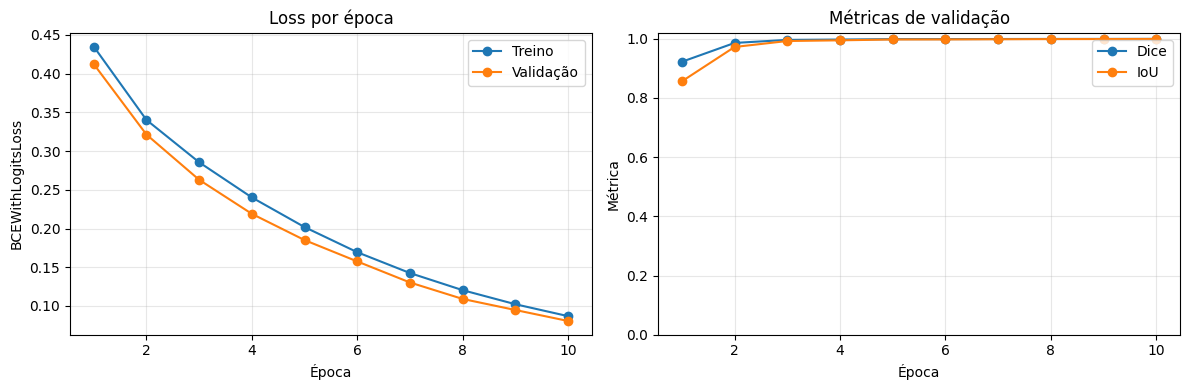

In [68]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Treino")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validação")
axes[0].set(title="Loss por época", xlabel="Época", ylabel="BCEWithLogitsLoss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["val_dice"], marker="o", label="Dice")
axes[1].plot(epochs, history["val_iou"], marker="o", label="IoU")
axes[1].set(title="Métricas de validação", xlabel="Época", ylabel="Métrica", ylim=(0, 1.02))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Avaliação semântica no conjunto de teste

Após selecionar os pesos pela menor loss de validação, avaliamos uma única vez no teste. Reportamos loss, Dice e IoU sem ajustar hiperparâmetros a partir desses resultados.

In [69]:
test_metrics = evaluate_semantic(model, test_loader, criterion, device)

assert all(np.isfinite(value) for value in test_metrics.values())
assert 0 <= test_metrics["dice"] <= 1
assert 0 <= test_metrics["iou"] <= 1

print("Resultados semânticos no teste sintético")
print("─" * 42)
print(f"Loss:  {test_metrics['loss']:.4f}")
print(f"Dice:  {test_metrics['dice']:.4f}")
print(f"IoU:   {test_metrics['iou']:.4f}")

Resultados semânticos no teste sintético
──────────────────────────────────────────
Loss:  0.0802
Dice:  0.9996
IoU:   0.9992


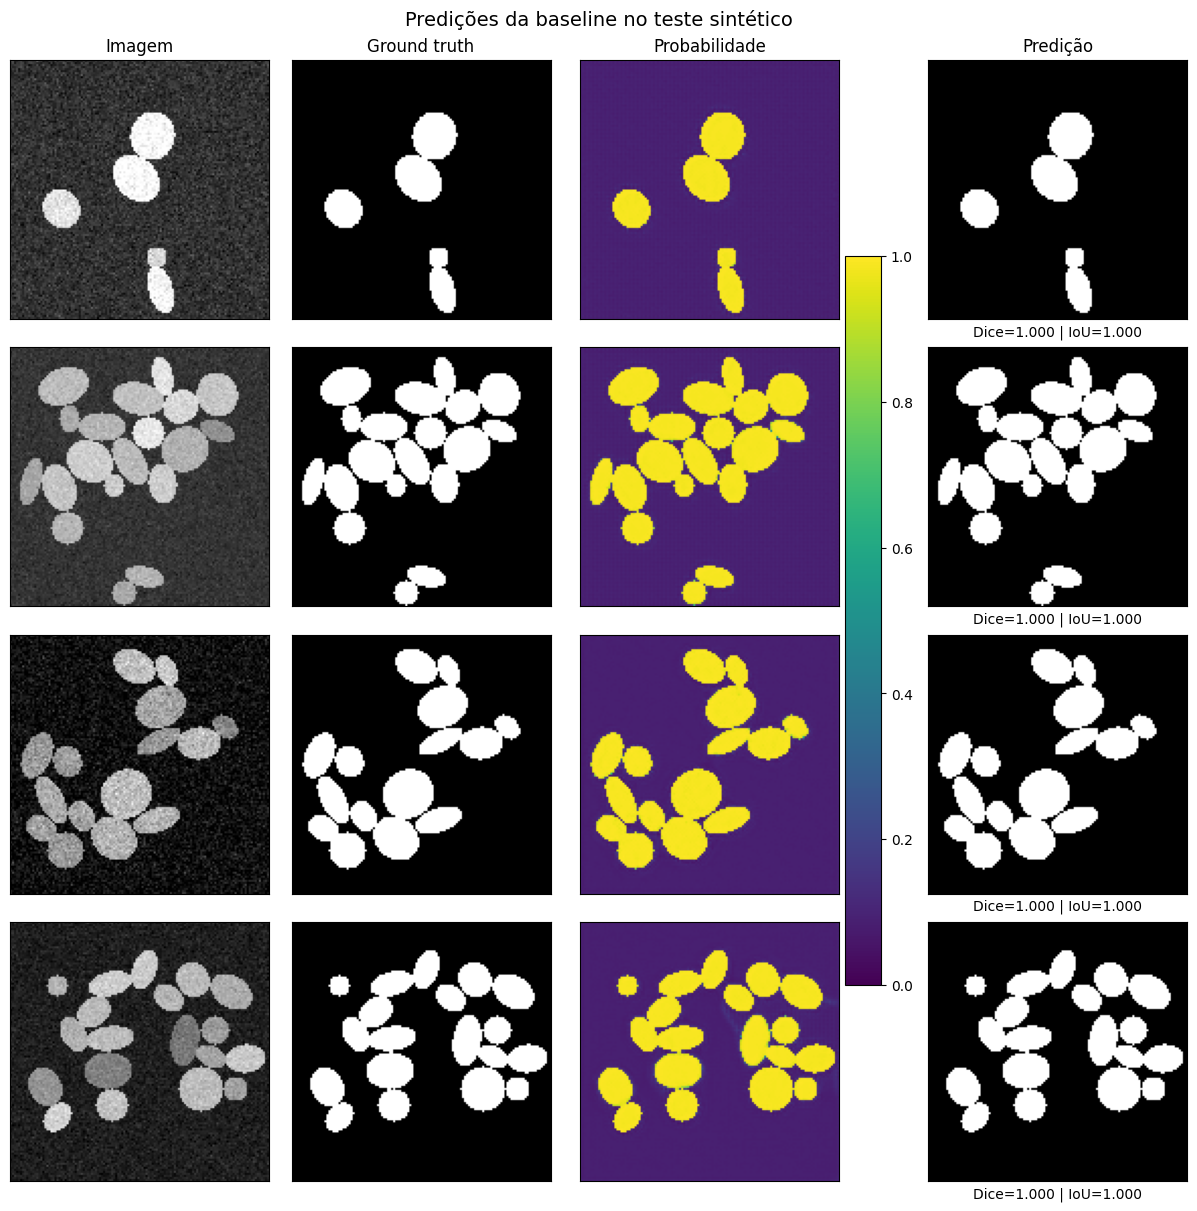

In [71]:
NUM_EXAMPLES = 4
example_batch = next(iter(test_loader))
example_images = example_batch["image"][:NUM_EXAMPLES].to(device)
example_targets = example_batch["binary_mask"][:NUM_EXAMPLES].to(device)

model.eval()
with torch.inference_mode():
    example_logits = model(example_images)
    example_probabilities = torch.sigmoid(example_logits)
    example_predictions = example_probabilities >= 0.5

images_np = example_images.cpu().numpy()
targets_np = example_targets.cpu().numpy()
probabilities_np = example_probabilities.cpu().numpy()
predictions_np = example_predictions.cpu().numpy()

fig, axes = plt.subplots(
    NUM_EXAMPLES, 4, figsize=(12, 3 * NUM_EXAMPLES), constrained_layout=True
)
column_titles = ["Imagem", "Ground truth", "Probabilidade", "Predição"]
for column, title in enumerate(column_titles):
    axes[0, column].set_title(title)

for row in range(NUM_EXAMPLES):
    sample_metrics = binary_segmentation_metrics(
        example_logits[row : row + 1], example_targets[row : row + 1]
    )
    axes[row, 0].imshow(images_np[row, 0], cmap="gray", vmin=0, vmax=1)
    axes[row, 1].imshow(targets_np[row, 0], cmap="gray", vmin=0, vmax=1)
    probability_plot = axes[row, 2].imshow(
        probabilities_np[row, 0], cmap="viridis", vmin=0, vmax=1
    )
    axes[row, 3].imshow(predictions_np[row, 0], cmap="gray", vmin=0, vmax=1)
    axes[row, 3].set_xlabel(
        f"Dice={sample_metrics['dice']:.3f} | IoU={sample_metrics['iou']:.3f}"
    )

for axis in axes.flat:
    axis.set_xticks([])
    axis.set_yticks([])
fig.colorbar(probability_plot, ax=axes[:, 2], shrink=0.65, pad=0.02)
fig.suptitle("Predições da baseline no teste sintético", fontsize=14)
plt.show()